In [8]:
# Re-import edits from itf.py so the notebook stops using the old version
%load_ext autoreload
%autoreload 2
import sys; sys.path.append("..") #tells python to go one folder up
import pyarrow
from src.ingest.itf import parse_itf, census_itf, parse_line, to_numeric, parse_itf_numeric, coord_issues, parse_itf_to_parts #brings in my functions

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
%%time
#this loads the dataset, and verifies its length
lines = open("../data/itf_slice100k.txt").read().splitlines() #this line simply sets my simplified dataset equal to "lines:
print(len(lines)) #prints how many lines, should be 100,000 for itf)slice100k.txt
#after first test, printed the correct number of lines

100000
CPU times: user 13.9 ms, sys: 14.6 ms, total: 28.6 ms
Wall time: 756 ms


In [10]:
%%time
#this cell will allow me to approx eyeball the raw structure, as it's a new file
for line in lines[:5]: #initiates a for loop, that will run for the first five lines
    print(repr(line)) #simply prints out everying on the line

'     /7239   4C2015 05 23.30928 11 55 25.17 -01 46 36.9          23.7 z1     T09'
'     /7239   4C2015 05 23.32686 11 55 25.34 -01 46 36.1          23.7 z1     T09'
'     /7239   4C2015 05 23.34140 11 55 25.49 -01 46 35.4          23.5 z1     T09'
'     /2050   4C2016 07 12.54696 23 31 53.92 -00 17 11.8          23.1 z1     T09'
'     /2050   4C2016 07 12.56833 23 31 54.24 -00 17 08.9          22.0 z1     T09'
CPU times: user 375 μs, sys: 86 μs, total: 461 μs
Wall time: 388 μs


In [11]:
%%time
#Cell copied over from the parsing of the 3I astrometry. Slightly modified.
import pandas as pd

rows = []
skipped_short = 0 #this creates a counter for lines we couldn't parse
skipped_pair = 0
for line in lines:
    if len(line) < 80: #if the line is shorter than 80
        skipped_short += 1
        continue
    if line[14].islower():
        skipped_pair += 1
        continue
    #the below is a fix to make the parser detect if there is a shift from an S at the start of the date, from if the observer was a space telescope. This should fix that error.
    off = 0 if line[15].isdigit() else 1
    rows.append({ #builds a list for the current line of all of its important info (normalizes data)
        "desig":    line[:12].strip(),
        "date_str": line[15+off:32+off].strip(),
        "ra_str":   line[32+off:44+off].strip(),
        "dec_str":  line[44+off:56+off].strip(),
        "mag_str":  line[65+off:70+off].strip(),
        "obscode":  line[77+off:80+off],
    })

df = pd.DataFrame(rows) #turns the list into a table
print(len(df), "parsed |", skipped_short, "short |", skipped_pair, "continuation") #prints how many rows were skipped, and how many made it to the table
df.head() #shows the first five rows of now parsed data

97746 parsed | 0 short | 2254 continuation
CPU times: user 237 ms, sys: 38.8 ms, total: 276 ms
Wall time: 323 ms


,desig,date_str,ra_str,dec_str,mag_str,obscode
0,/7239,2015 05 23.30928,11 55 25.17,-01 46 36.9,23.7,T09
1,/7239,2015 05 23.32686,11 55 25.34,-01 46 36.1,23.7,T09
2,/7239,2015 05 23.34140,11 55 25.49,-01 46 35.4,23.5,T09
3,/2050,2016 07 12.54696,23 31 53.92,-00 17 11.8,23.1,T09
4,/2050,2016 07 12.56833,23 31 54.24,-00 17 08.9,22.0,T09


In [12]:
%%time
#This cell will measure the memory that all lines take up

gb = df.memory_usage(deep=True).sum() / 1e9 #counts the true cost of everything, includeing strings, it then totals all columns, then converts bytes to GB
print(round(gb, 3), "GB for 100k lines")

0.01 GB for 100k lines
CPU times: user 2.86 ms, sys: 970 μs, total: 3.83 ms
Wall time: 5.18 ms


In [13]:
%%time
#this cell will extrapolate based off all the numbers/data i've collected so far, to calculate how long it will take, and how much space it will take up

TOTAL = 9354883 #the total amount of lines
t_slice = 0.544 #the amount of time it took to parse 100k lines
gb_slice = 0.034 #the amount of data used for the 100k lines

scale = TOTAL / 100000 #this determines what we need to scale our current data and time values by
print("projected parse time:", round(t_slice * scale / 60, 1), "minutes") #calculates how long its expected to parse by multipling our current value by the scale factor, and then converting it to minutes, as its currently in milliseconds
print("projected dataframe:", round(gb_slice * scale, 1), "GB") #does the same as above, but for gigabytes 

projected parse time: 0.8 minutes
projected dataframe: 3.2 GB
CPU times: user 336 μs, sys: 0 ns, total: 336 μs
Wall time: 298 μs


In [14]:
%%time
#"flag" census

from collections import Counter #imports python's counter
flags = Counter(line[14] for line in lines if len(line) >= 80) #this parses through all 100000 lines, and adds the charachter at index 14 to the flag variable, whenever the length is above or equal to 80 length
print(flags.most_common(10)) #prints out the 10 most common flags


[('C', 95470), ('S', 2254), ('s', 2254), ('B', 16), (' ', 6)]
CPU times: user 10.7 ms, sys: 0 ns, total: 10.7 ms
Wall time: 10.6 ms


In [15]:
%%time
#This is a validator cell, to ensure that every weird line gets caught before going to the next few cells
looks_ok = df["ra_str"].str.match(r"^\d{2} \d{2} \d{2}") #this line tests every entry in the ra_str column against a pattern, only passing lines that pass the pattern, testing each invididual row. The pattern itself checks to ensure that starting at the very beginning of the string, there are exactly 3 pairs of two digits seperated by spaces.
print((~looks_ok).sum(), "suspicious rows") #the ~ means not, and flips every true to false and visa versa, so looks ok then marks the rows that failed the test, so we know how many failed without creating a new variable. .sum simply counts how many of these failures there are, and the print tells me the quantity
df[~looks_ok].head() #This line prints out the first five rows that didn't pass the test.

0 suspicious rows
CPU times: user 7.67 ms, sys: 2.16 ms, total: 9.83 ms
Wall time: 13.4 ms


,desig,date_str,ra_str,dec_str,mag_str,obscode


In [16]:
%%time
#this cell will preform structural checks
print(df["desig"].value_counts().head(10)) #Will print the "biggest" tracklets in the file
print(df["obscode"].value_counts().head(10)) #Which observatories are in the head of the file
print(df["desig"].nunique(), "distinct designations in file slice") #prints out the number of different objects in this file

desig
0001198    32
0003065    30
0001935    28
0003154    26
0000781    23
0001501    23
06AQUV     23
0001508    22
0000533    21
0023651    21
Name: count, dtype: int64
obscode
705    81145
699    10931
C51     2254
Z18      846
568      568
Z32      468
608      183
J75      156
W92      101
I41       73
Name: count, dtype: int64
45623 distinct designations in file slice
CPU times: user 12.2 ms, sys: 1.03 ms, total: 13.2 ms
Wall time: 12.6 ms


In [17]:
df_s, stats_s = parse_itf("../data/itf_slice100k.txt") #runs the parsing function on the 100k line practice file, gives the two things the function returns names
print(stats_s) #Shows the counts
print(len(df_s) == 97746, ": module gives the same answer as cell from tuesday") #compares how many lines were actually parsed to tuesday's values, should print true

{'parsed': 97746, 'skipped': 2254}
True : module gives the same answer as cell from tuesday


In [18]:
#%%time
#df, stats = parse_itf("../data/itf.txt") #parses it
#print(stats) #prints the stats
#print(len(df), "rows in full ITF table") #prints num rows

{'parsed': 9235767, 'skipped': 119116, 'bad_ra': 38918}
[('F51', 2720677), ('W84', 1197169), ('G96', 1085281), ('F52', 1038077), ('T09', 871810), ('V00', 485629), ('705', 462223), ('691', 259477), ('703', 127381), ('644', 102570), ('309', 97879), ('699', 92473), ('568', 72077), ('695', 67819), ('807', 64994)]
42.4 percent from top two
1858 3
1889 1
1901 1
1920 6
1950 2
1951 6
1953 14
1954 12
1955 14
1956 8
1960 6
1974 2
1975 2
1976 8
1977 2
1978 12
1981 18
1982 13
1983 8
1984 2
1985 8
1986 4
1987 2
1988 38
1990 219
1991 864
1992 675
1993 1217
1994 1593
1995 2691
1996 2776
1997 2768
1998 24404
1999 13181
2000 37221
2001 42256
2002 35794
2003 58483
2004 46016
2005 308723
2006 335316
2007 195071
2008 111901
2009 92749
2010 140931
2011 148190
2012 133242
2013 218397
2014 519118
2015 747948
2016 626496
2017 525470
2018 313563
2019 821873
2020 543218
2021 737552
2022 571574
2023 522220
2024 566167
2025 548315
2026 237383
2592215 designations | mean 3.56 | median 3.0


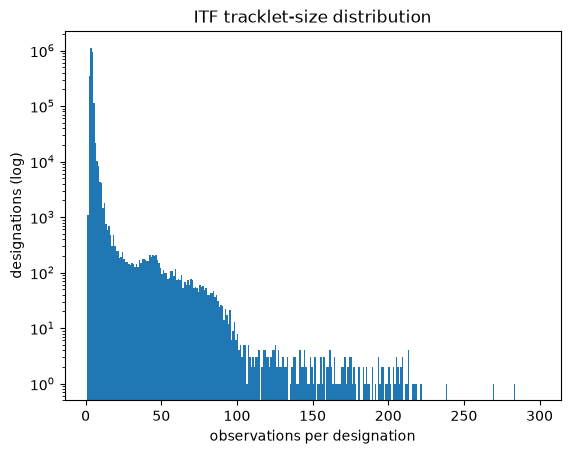

283
[('tnoa002', 283), ('soho181', 269), ('tnoa009', 238), ('RL00TZQ', 221), ('RL00U5M', 218)]


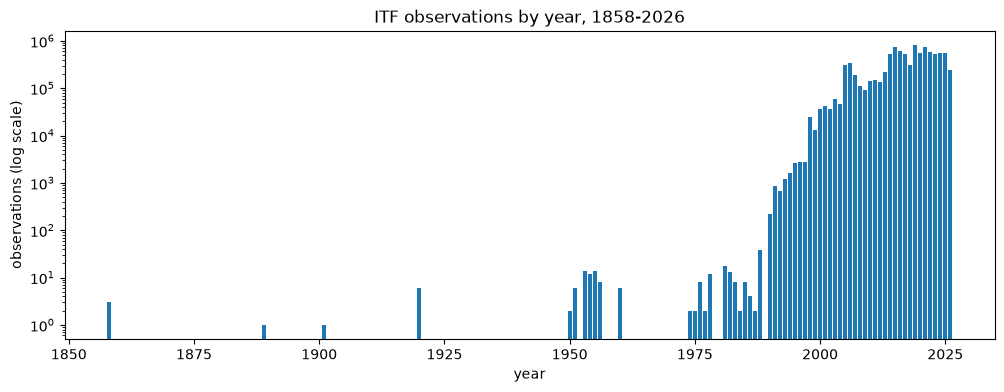

CPU times: user 46.6 s, sys: 2.24 s, total: 48.8 s
Wall time: 1min 21s


In [19]:
%%time
import numpy as np
import matplotlib.pyplot as plt

obs, years, sizes, stats = census_itf("../data/itf.txt") #runs the function
print(stats) #prints the rsults of the function
print(obs.most_common(15)) #prints the 15 most common observatories throughout the ENTIRE file
top2 = sum(n for _, n in obs.most_common(2)) #creates top2, with the top 2 observatories
print(round(top2 / stats["parsed"] * 100, 1), "percent from top two") #Calculaes and prints what percent of all observations were made by the top two observatories

for y in sorted(years): #the groth history of the file, in year order
    print(y, years[y])

counts = np.fromiter(sizes.values(), dtype=np.int32) #counter values into compact number array
print(len(counts), "designations | mean", round(counts.mean(), 2), "| median", np.median(counts))

#the below is all to create a plot of this
plt.hist(counts, bins=range(1, 300))
plt.yscale("log")
plt.xlabel("observations per designation"); plt.ylabel("designations (log)")
plt.title("ITF tracklet-size distribution")
#plt.savefig("../figures/itf_tracklet_sizes_V1.png", dpi=150)
plt.show()
print(max(counts))
print(sizes.most_common(5))

year_nums = sorted(int(y) for y in years) #turns counter keys into real numbers, in order
year_counts = [years[str(y)] for y in year_nums] #gets each year's tally back, in the same order as the counter keys
#the below is all for the second graph, for the year data
plt.figure(figsize=(12, 4))
plt.bar(year_nums, year_counts)
plt.yscale("log")
plt.xlabel("year")
plt.ylabel("observations (log scale)")
plt.title("ITF observations by year, 1858-2026")
#plt.savefig("../figures/itf_by_year_V1.png", dpi=150)
plt.show()

In [20]:
print(obs["I41"])

6910


In [21]:
%%time
#this cell will apply to_numeric to df
df = to_numeric(df)

CPU times: user 10.2 s, sys: 182 ms, total: 10.4 s
Wall time: 11.3 s


In [22]:
%%time
#this cell will inspect df after to_numeric was applied, by printing out head
df[["ra_deg", "dec_deg", "time"]].head()
df.memory_usage(deep=True)

CPU times: user 3.97 ms, sys: 0 ns, total: 3.97 ms
Wall time: 6.61 ms


Index           132
desig       1372363
date_str    2351544
ra_str      1859531
dec_str     1859537
mag_str     1139052
obscode     1075206
ra_deg       781968
dec_deg      781968
time         781968
dtype: int64

In [23]:
parse_itf_numeric #function receipt, proves it was successfully uploaded.

<function src.ingest.itf.parse_itf_numeric(path, batch_size=500000, keep=None)>

In [24]:
%%time
#will test the function on the 100k file slice.
KEEP = ["desig", "obscode", "ra_deg", "dec_deg", "time", "fmt"] 
test = parse_itf_numeric("../data/itf_slice100k.txt", batch_size=20000) #sets the batch size to 20,000, because 500,000 rows would never fill in the 100k row file.
test.head(10)

20,000 rows done
40,000 rows done
60,000 rows done
80,000 rows done
CPU times: user 11.1 s, sys: 86.7 ms, total: 11.2 s
Wall time: 11.7 s


,desig,date_str,ra_str,dec_str,fmt,obscode,ra_deg,dec_deg,time
0,/7239,2015 05 23.30928,11 55 25.17,-01 46 36.9,standard,T09,178.854875,-1.776917,2015-05-23 07:25:21.792000
1,/7239,2015 05 23.32686,11 55 25.34,-01 46 36.1,standard,T09,178.855583,-1.776694,2015-05-23 07:50:40.704000
2,/7239,2015 05 23.34140,11 55 25.49,-01 46 35.4,standard,T09,178.856208,-1.776500,2015-05-23 08:11:36.960000
3,/2050,2016 07 12.54696,23 31 53.92,-00 17 11.8,standard,T09,352.974667,-0.286611,2016-07-12 13:07:37.344000
4,/2050,2016 07 12.56833,23 31 54.24,-00 17 08.9,standard,T09,352.976000,-0.285806,2016-07-12 13:38:23.712000
5,/2050,2016 07 12.58992,23 31 54.57,-00 17 05.7,standard,T09,352.977375,-0.284917,2016-07-12 14:09:29.088000
6,,2018 11 15.451331,23 09 38.88,+19 56 53.7,standard,381,347.412000,19.948250,2018-11-15 10:49:54.998400
7,,2018 11 15.465069,23 18 41.46,+19 31 50.8,standard,381,349.672750,19.530778,2018-11-15 11:09:41.961600
8,,2018 11 15.465243,23 18 48.26,+19 31 31.0,standard,381,349.701083,19.525278,2018-11-15 11:09:56.995200
9,/3469,2024 09 09.98550,19 12 06.972,-26 24 14.38,standard,303,288.029050,-26.403994,2024-09-09 23:39:07.200000


In [25]:
%%time
#diagnostic cell
d = test["desig"].fillna("").astype(str).str.strip()
print("rows:           ", len(test))
print("blank desig:    ", (d == "").sum())
print("starts with '/':", d.str.startswith("/").sum())
print("distinct desig: ", test["desig"].nunique())

rows:            97746
blank desig:     3
starts with '/': 645
distinct desig:  45623
CPU times: user 9.04 ms, sys: 6.89 ms, total: 15.9 ms
Wall time: 41.1 ms


In [26]:
%%time
#this cell should can the entire itf file for "offenders" like the one found in the cell below, where there was somehow a 78 hour RA.
#after the parse_line update, this cell is obselete, but it initially handed back a total of 93,363 rows with out of range RA values.
bad = []
with open("../data/itf.txt") as f:
    for i, line in enumerate(f):
        row = parse_line(line)
        if not row:
            continue
        ra = row["ra_str"]
        try:
            hours = int(ra.split()[0]) 
        except (ValueError, IndexError):
            bad.append((i, ra, line)); continue
        if not (0 <= hours < 24):
            bad.append((i, ra, line))

print(f"{len(bad):,} rows with out of range RA values.") #prints out rows, adds commas to number

0 rows with out of range RA values.
CPU times: user 34.4 s, sys: 640 ms, total: 35.1 s
Wall time: 36.4 s


In [27]:
%%time
#this cell should find similarities between this kind of "bad" cells
from collections import Counter
for i, ra, line in bad[:5]:
    print(repr(line))
print(Counter(len(line.rstrip("\n")) for _, _, line in bad).most_common())

[]
CPU times: user 398 μs, sys: 16 μs, total: 414 μs
Wall time: 344 μs


In [28]:
%%time
#This cell will ensure that the fix worked, by intentionally feeding it an actual line.
from src.ingest.itf import parse_line, to_numeric
import pandas as pd

bad_line = '     /9230    C2020 10 20.81777778 23 22.58 -11 02 45.1          16.6 VV     470\n'
row = parse_line(bad_line)
print(row["ra_str"], "|", row["fmt"]) #I expect 23 22.58 | long_date

df1 = to_numeric(pd.DataFrame([row]))
print(df1["ra_deg"].iloc[0]) #I expect ~350.645

23 22.58 | long_date
350.645
CPU times: user 4.99 ms, sys: 1.03 ms, total: 6.02 ms
Wall time: 5.35 ms


In [29]:
%%time
#finds the number of bad DEC lines
bad_dec = []
with open("../data/itf.txt") as f:
    for i, line in enumerate(f):
        row = parse_line(line)
        if not row:
            continue
        if len(row["dec_str"].split()) != 3: #a normal dec only has exactly 3 fields, so this wil check for not that
            bad_dec.append((i, row["dec_str"], row["fmt"], line))
print(len(bad_dec), "suspicious decs")

#for i, dec, fmt, line in bad_dec:
#    print(fmt, "|", repr(dec))
#    print(repr(line))

0 suspicious decs
CPU times: user 31.5 s, sys: 599 ms, total: 32.1 s
Wall time: 33.3 s


In [30]:
%%time
#this cell should find all bad rows in the enitre ITF file (using the coord_issues function), so I can fix the parser to adjust for all of them before I have to go through another 10+ minute run just for the program to crash.
from collections import Counter

reasons, fmts, date_decimals, samples = Counter(), Counter(), Counter(), [] #creates four different collectors in one line. Reasons will tally which problems occured, fmts will tally the standard vs. long_date among the rows already classified as bad, date_decimals will tally how many decimals the date had, and samples will store a few example rows.
with open("../data/itf.txt") as f:
    for line in f:
        row = parse_line(line) #parses the line
        if not row: #if there was a skipped line, it will simply just skip the rest of it, so only real rows "go on"
            continue
        issues = coord_issues(row["ra_str"], row["dec_str"]) #runs the isue finder on the current row's RA and Dec values, issues is the list of problems
        if issues: #if this row had any problem
            reasons.update(issues) #adds each new problem to the reasons array
            fmts[row["fmt"]] += 1 #increases the count for this bad row's formatting error tag, tells us what type of bad rows are there.
            #the following two lines will work out how many decimal places are in this row's date and tallies it. d.split(".")[-1] takes everything after the last dot, and len() counts the decimal places. if "." in d else 0 "guards" a date with no dot. This links bad coordinates to precision (extra decimal places)
            d = row["date_str"]
            date_decimals[len(d.split(".")[-1]) if "." in d else 0] += 1
            if len(samples) < 10: #this if saves the first ten bad rows as examples, so we can look at what makes them up.
                samples.append((row["fmt"], row["ra_str"], row["dec_str"], line))
print("total bad rows: ", sum(fmts.values()))
print("by reason: ", dict(reasons))
print("by fmt: ", dict(fmts))
print("by date decimals: ", dict(date_decimals))
print()
for fmt, ra, dec, line in samples: #Unpacks each item into named variables, repr() shows everything, to count everything.
    print(fmt, "| ra=", repr(ra), "| dec=", repr(dec))
    print(" ", repr(line))


total bad rows:  0
by reason:  {}
by fmt:  {}
by date decimals:  {}

CPU times: user 41.9 s, sys: 686 ms, total: 42.6 s
Wall time: 44 s


In [31]:
import pyarrow; print(pyarrow.__version__)

25.0.0


In [41]:
%%time
import pyarrow
itf = parse_itf_to_parts("../data/itf.txt", "../data/itf_numeric", keep=KEEP)

500,000 rows written
1,000,000 rows written
1,500,000 rows written
2,000,000 rows written
2,500,000 rows written
3,000,000 rows written
3,500,000 rows written
4,000,000 rows written
4,500,000 rows written
5,000,000 rows written
5,500,000 rows written
6,000,000 rows written
6,500,000 rows written
7,000,000 rows written
7,500,000 rows written
8,000,000 rows written
8,500,000 rows written
9,000,000 rows written
CPU times: user 16min 59s, sys: 21.8 s, total: 17min 21s
Wall time: 18min 9s


In [42]:
%%time
#result analysis block
itf = pd.read_parquet("../data/itf_numeric")
print(len(itf), "is the itf length")
print(9_290_215 - len(itf), "lines rejected")
print(itf.dtypes)
itf.head()
itf["fmt"].value_counts()
itf["obscode"].value_counts().head(8)

9235767 is the itf length
54448 lines rejected
desig                 str
obscode               str
ra_deg            float64
dec_deg           float64
time       datetime64[us]
fmt                   str
dtype: object
CPU times: user 1.55 s, sys: 1.41 s, total: 2.96 s
Wall time: 3.39 s


obscode
F51    2720677
W84    1197169
G96    1085281
F52    1038077
T09     871810
V00     485629
705     462223
691     259477
Name: count, dtype: int64

In [43]:
%%time
#this cell should confimrm what's actually on the disk
import os, pandas as pd
folder = "../data/itf_numeric"
parts = sorted(f for f in os.listdir(folder) if f.endswith(".parquet"))
print("parts on disk:", len(parts))
total = 0
for p in parts:
    n = len(pd.read_parquet(f"{folder}/{p}")) #read one part, count its rows
    total += n
    print(p, n)
print("Total rows on disk:", total)

parts on disk: 19
part_000.parquet 500000
part_001.parquet 500000
part_002.parquet 500000
part_003.parquet 500000
part_004.parquet 500000
part_005.parquet 500000
part_006.parquet 500000
part_007.parquet 500000
part_008.parquet 500000
part_009.parquet 500000
part_010.parquet 500000
part_011.parquet 500000
part_012.parquet 500000
part_013.parquet 500000
part_014.parquet 500000
part_015.parquet 500000
part_016.parquet 500000
part_017.parquet 500000
part_018.parquet 235767
Total rows on disk: 9235767
CPU times: user 1.24 s, sys: 197 ms, total: 1.43 s
Wall time: 2.14 s
